# Comparing dismantling strategies

In [ ]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import 

### (1) Write the code to remove a list of nodes from a given network 
     - The list can be a random subset of nodes (ie, failures) → percolation 
     - The list can be a subset of ranked nodes (ie, attacks) → optimal dismantling

In [9]:
import numpy as np
from scipy.stats import norm

def percolation(g, prob):
    
    '''
    Remove vertices with a given probability
    '''

    n_removals = int(np.ceil(prob * g.vcount()))
    idx = np.random.choice(g.vcount(), size=n_removals, replace=False)

    g.delete_vertices(idx)
    
    return g


def unif_optimal_dismantling(g, a_deg, b_deg, n_removals):
    
    '''
    Remove vertices with degree in the range [a_deg, b_deg] with uniform probability
    '''
    
    all_degrees = g.degree()
    idx = [i for i, d in enumerate(all_degrees) if a_deg <= d <= b_deg]
    
    if n_removals < len(idx):
        idx_remove = np.random.choice(idx, size=n_removals, replace=False)
    else: 
        idx_remove = idx
        
    g.delete_vertices(idx_remove)

    return g


def gauss_optimal_dismantling(g, mu, sigma, n_removals):

    '''
    Remove vertices with degree around mu with a Gaussian probability distribution
    '''

    all_degrees = g.degree()
    idx = list(range(g.vcount()))
    
    if n_removals < len(idx):
        raw_weights = np.array([norm.pdf(d, loc=mu, scale=sigma) for d in all_degrees])
        prob = raw_weights / raw_weights.sum()
        idx_remove = np.random.choice(idx, size=n_removals, replace=False, p=prob)
    else: 
        idx_remove = idx
        
    g.delete_vertices(idx_remove)
    
    return g

### (2) Specifics for synthetic networks analysis 
     - Use N = 5000 (or larger); consider 20 instances of Erdos-Renyi and Barabasi-Albert with same average degree 
     - Calculate how the relative size of the LCC change after removing a fraction p of nodes
     - Compare: random failures vs degree-ranking vs betweenness-ranking attacks

In [18]:
random_seed = 42
np.random.seed(random_seed) # for reproducibility

N = 10000
avg_degree = 10

probability_values = np.linspace(0.01, 0.95, 10)
N_iterations = 10

LCC_erdosrenyi_random = {}
LCC_erdosrenyi_uniform = {}
LCC_erdosrenyi_gaussian = {}

LCC_barabasi_random = {}
LCC_barabasi_uniform = {}
LCC_barabasi_gaussian = {}

for p in probability_values:

    LCC_erdosrenyi_random[p] = []
    LCC_erdosrenyi_uniform[p] = []
    LCC_erdosrenyi_gaussian[p] = []

    LCC_barabasi_random[p] = []
    LCC_barabasi_uniform[p] = []
    LCC_barabasi_gaussian[p] = []

    for _ in range(N_iterations):

        a_degree = avg_degree + 2

        # Erdos-Renyi dismantling
        m = int(N * avg_degree / 2)
        g = ig.Graph.Erdos_Renyi(n=N, m=m)
        b_degree = max(g.degree())
        g_erdosrenyi_random = percolation(g.copy(), p)
        g_erdosrenyi_uniform = unif_optimal_dismantling(g.copy(), a_deg=a_degree, b_deg=b_degree, n_removals=int(p * N))
        g_erdosrenyi_gaussian = gauss_optimal_dismantling(g.copy(), mu=avg_degree, sigma=2, n_removals=int(p * N))

        LCC_erdosrenyi_random[p].append(g_erdosrenyi_random.connected_components().giant().vcount() / N)
        LCC_erdosrenyi_uniform[p].append(g_erdosrenyi_uniform.connected_components().giant().vcount() / N)
        LCC_erdosrenyi_gaussian[p].append(g_erdosrenyi_gaussian.connected_components().giant().vcount() / N)

        # Barabasi-Albert dismantling
        g = ig.Graph.Barabasi(n=N, m=avg_degree)
        b_degree = max(g.degree())
        g_barabasi_random = percolation(g.copy(), p)
        g_barabasi_uniform = unif_optimal_dismantling(g.copy(), a_deg=a_degree, b_deg=b_degree, n_removals=int(p * N))
        g_barabasi_gaussian = gauss_optimal_dismantling(g.copy(), mu=avg_degree, sigma=2, n_removals=int(p * N))

        LCC_barabasi_random[p].append(g_barabasi_random.connected_components().giant().vcount() / N)
        LCC_barabasi_uniform[p].append(g_barabasi_uniform.connected_components().giant().vcount() / N)
        LCC_barabasi_gaussian[p].append(g_barabasi_gaussian.connected_components().giant().vcount() / N)
    
    # Compute average LCC size for each method and probability
    LCC_erdosrenyi_random[p] = np.mean(LCC_erdosrenyi_random[p])
    LCC_erdosrenyi_uniform[p] = np.mean(LCC_erdosrenyi_uniform[p])
    LCC_erdosrenyi_gaussian[p] = np.mean(LCC_erdosrenyi_gaussian[p])
    LCC_barabasi_random[p] = np.mean(LCC_barabasi_random[p])
    LCC_barabasi_uniform[p] = np.mean(LCC_barabasi_uniform[p])
    LCC_barabasi_gaussian[p] = np.mean(LCC_barabasi_gaussian[p])

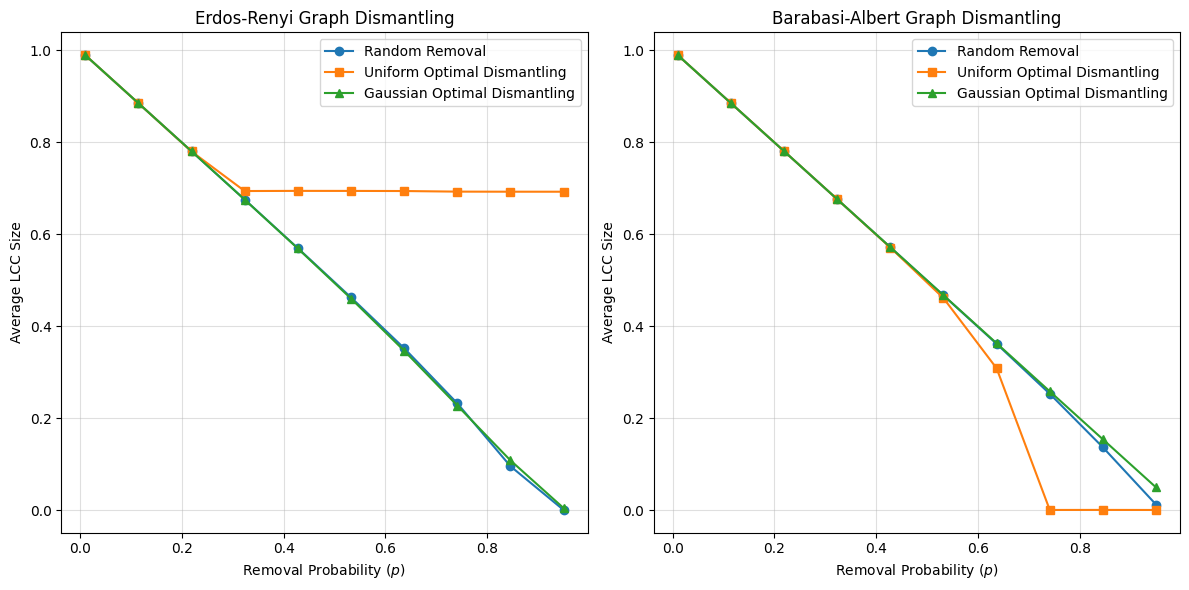

In [19]:
# Plotting results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(probability_values, list(LCC_erdosrenyi_random.values()), label='Random Removal', marker='o')
plt.plot(probability_values, list(LCC_erdosrenyi_uniform.values()), label='Uniform Optimal Dismantling', marker='s')
plt.plot(probability_values, list(LCC_erdosrenyi_gaussian.values()), label='Gaussian Optimal Dismantling', marker='^')
plt.title('Erdos-Renyi Graph Dismantling')
plt.xlabel('Removal Probability ($p$)')
plt.ylabel('Average LCC Size')
plt.grid(True, alpha=0.4)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(probability_values, list(LCC_barabasi_random.values()), label='Random Removal', marker='o')
plt.plot(probability_values, list(LCC_barabasi_uniform.values()), label='Uniform Optimal Dismantling', marker='s')
plt.plot(probability_values, list(LCC_barabasi_gaussian.values()), label='Gaussian Optimal Dismantling', marker='^')
plt.title('Barabasi-Albert Graph Dismantling')
plt.xlabel('Removal Probability ($p$)')
plt.ylabel('Average LCC Size') 
plt.grid(True, alpha=0.4)   
plt.legend()

plt.tight_layout()
plt.show()